In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# For prettier plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# =========================
# 1. DATA LOADING
# =========================
df = pd.read_csv("yield_df.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (28242, 8)


In [3]:
# =========================
# 2. DATA INSPECTION
# =========================

print("\n--- First 5 rows ---")
print(df.head())


--- First 5 rows ---
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  


In [4]:
print("\n--- Info ---")
print(df.info())


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB
None


In [5]:
print("\n--- Summary statistics (numeric columns) ---")
print(df.describe())


--- Summary statistics (numeric columns) ---
         Unnamed: 0          Year    hg/ha_yield  \
count  28242.000000  28242.000000   28242.000000   
mean   14120.500000   2001.544296   77053.332094   
std     8152.907488      7.051905   84956.612897   
min        0.000000   1990.000000      50.000000   
25%     7060.250000   1995.000000   19919.250000   
50%    14120.500000   2001.000000   38295.000000   
75%    21180.750000   2008.000000  104676.750000   
max    28241.000000   2013.000000  501412.000000   

       average_rain_fall_mm_per_year  pesticides_tonnes      avg_temp  
count                    28242.00000       28242.000000  28242.000000  
mean                      1149.05598       37076.909344     20.542627  
std                        709.81215       59958.784665      6.312051  
min                         51.00000           0.040000      1.300000  
25%                        593.00000        1702.000000     16.702500  
50%                       1083.00000       17529.4400

In [6]:
print("\n--- Missing values in each column ---")
print(df.isnull().sum())

print("\n--- Unique values in 'Area' and 'Item' ---")
print("Unique Areas:", df["Area"].nunique())
print("Unique Items:", df["Item"].nunique())


--- Missing values in each column ---
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

--- Unique values in 'Area' and 'Item' ---
Unique Areas: 101
Unique Items: 10


In [7]:
# =========================
# 3. DATA PROCESSING
# =========================

# 3.1 Remove exact duplicate rows if any
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\nRemoved {before - after} duplicate rows.")


Removed 0 duplicate rows.


In [8]:
# 3.2 Handle missing values
numeric_cols = ["Year", "hg/ha_yield", "average_rain_fall_mm_per_year",
                "pesticides_tonnes", "avg_temp"]
cat_cols = ["Area", "Item"]

# Fill numeric missing values with median
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Fill categorical missing values with mode
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("\nMissing values after imputation:")
print(df.isnull().sum())



Missing values after imputation:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [9]:
# 3.3 Basic outlier handling
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print("\nNumeric columns clipped at 1st and 99th percentiles to handle outliers.")


Numeric columns clipped at 1st and 99th percentiles to handle outliers.


In [10]:
# 3.4 Feature Engineering: create binary target "yield_label"
# High yield (1) if above or equal median, else low yield (0)
yield_median = df["hg/ha_yield"].median()
df["yield_label"] = (df["hg/ha_yield"] >= yield_median).astype(int)

print(f"\nYield median value: {yield_median}")
print(df["yield_label"].value_counts())
print("0 = Low yield, 1 = High yield")


Yield median value: 38295.0
yield_label
1    14124
0    14118
Name: count, dtype: int64
0 = Low yield, 1 = High yield


In [11]:
# =========================
# 3.5 ENCODING CATEGORICAL VARIABLES (REPLACEMENT)
# =========================
# Instead of one-hot for Area/Item (which creates too many sparse features),
# use frequency encoding (stable, simple, avoids dimensional explosion).
cat_cols = ["Area", "Item"]

# Create a copy of the dataframe to encode
df_enc = df.copy()

for col in cat_cols:
    freq = df_enc[col].value_counts(normalize=True)
    df_enc[col + "_freq"] = df_enc[col].map(freq)
# drop original categorical columns (we keep their frequency encodings)
df_enc = df_enc.drop(columns=cat_cols)

print("\nColumns after frequency encoding:")
print(df_enc.columns.tolist())

# use df_enc going forward
df_encoded = df_enc.copy()


Columns after frequency encoding:
['Unnamed: 0', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'yield_label', 'Area_freq', 'Item_freq']


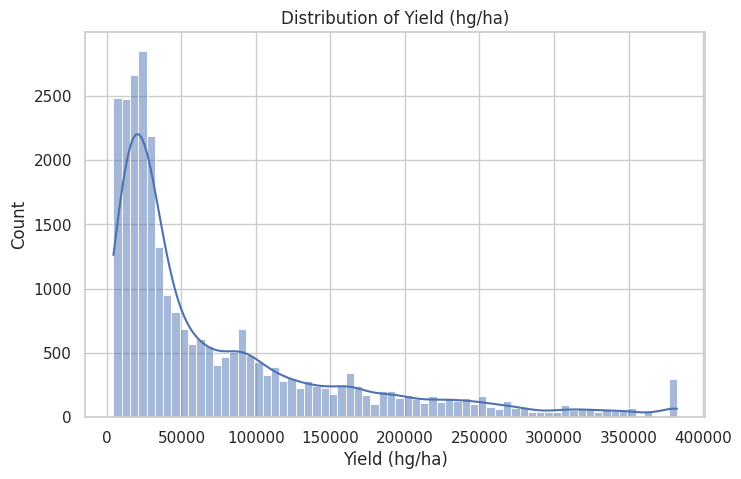

In [12]:
# =========================
# 4. EXPLORATORY DATA ANALYSIS
# =========================

# 4.1 Distribution of yield
plt.figure()
sns.histplot(df["hg/ha_yield"], kde=True)
plt.title("Distribution of Yield (hg/ha)")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Count")
plt.show()

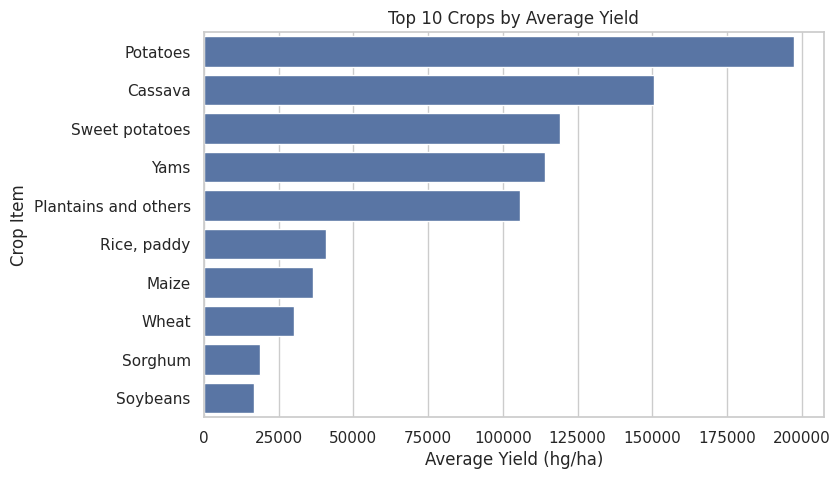

In [13]:
# 4.2 Average yield by Item
plt.figure()
top_items = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_items.values, y=top_items.index)
plt.title("Top 10 Crops by Average Yield")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Crop Item")
plt.show()

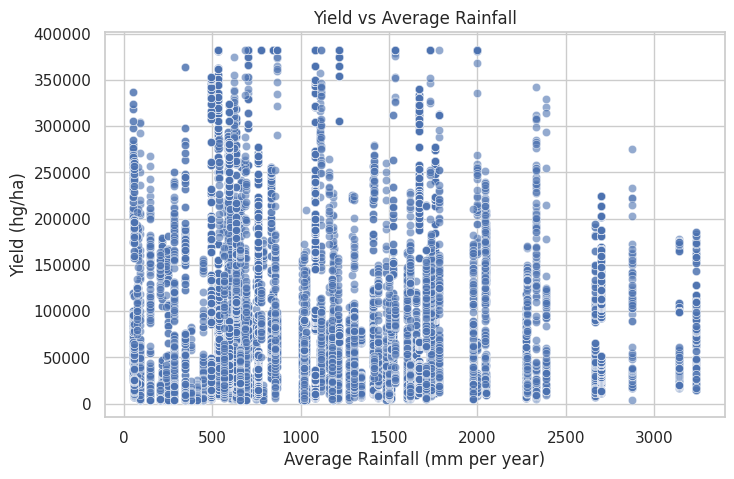

In [14]:
# 4.3 Relationship between rainfall and yield
plt.figure()
sns.scatterplot(x="average_rain_fall_mm_per_year", y="hg/ha_yield", data=df, alpha=0.6)
plt.title("Yield vs Average Rainfall")
plt.xlabel("Average Rainfall (mm per year)")
plt.ylabel("Yield (hg/ha)")
plt.show()

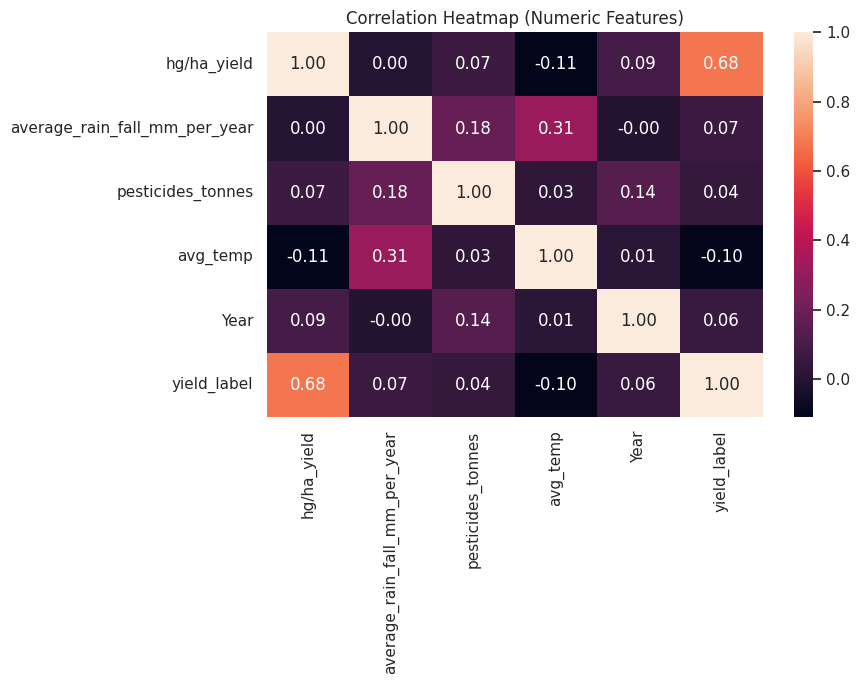

In [15]:
# 4.4 Correlation heatmap of numeric variables
plt.figure()
corr = df_encoded[["hg/ha_yield", "average_rain_fall_mm_per_year",
                   "pesticides_tonnes", "avg_temp", "Year", "yield_label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [16]:
# =========================
# 5. FINALIZE X AND y (UPDATED)
# =========================
# Keep using your previously created binary target 'yield_label'
feature_cols = df_encoded.columns.tolist()
if "yield_label" not in feature_cols:
    raise KeyError("yield_label not found in dataframe — ensure you ran feature engineering earlier.")
feature_cols.remove("yield_label")

X = df_encoded[feature_cols].copy()
y = df_encoded["yield_label"].copy()

print("\nFinal feature matrix shape (after freq-encoding):", X.shape)
print("Final target shape:", y.shape)


Final feature matrix shape (after freq-encoding): (28242, 8)
Final target shape: (28242,)


In [17]:
# =========================
# 6. TRAIN–TEST SPLIT (unchanged)
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (22593, 8) Test shape: (5649, 8)


In [18]:
# =========================
# 7. SCALING + TRAINING (GAUSSIAN NAIVE BAYES)
# =========================
# Build numeric column list (all columns should be numeric now)
numeric_cols_all = X_train.columns.tolist()
n_feats = X_train.shape[1]

# Preprocessing pipelines:
#  - standard_pipeline: median impute + StandardScaler (good for GaussianNB)
#  - nonneg_pipeline: median impute + MinMaxScaler (to make features non-negative for ComplementNB)
standard_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nonneg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())   # scales to [0,1] so ComplementNB won't see negative values
])

preprocessor_standard = ColumnTransformer([
    ("num", standard_pipeline, numeric_cols_all)
], remainder="drop")

preprocessor_nonneg = ColumnTransformer([
    ("num", nonneg_pipeline, numeric_cols_all)
], remainder="drop")

# Master pipeline: preprocessing -> feature selection -> classifier
pipe = Pipeline([
    ("preproc", preprocessor_standard),          # placeholder; overridden in GridSearchCV where needed
    ("select", SelectKBest(score_func=mutual_info_classif, k="all")),
    ("clf", GaussianNB())
])

# Parameter grid:
k_candidates = ["all", min(20, n_feats), min(50, n_feats)]
# remove duplicates and ensure valid ints
k_candidates = sorted(list(dict.fromkeys(k_candidates)), key=lambda x: (x == "all", x))  # keep 'all' last if present

param_grid = [
    # GaussianNB with standard preprocessing
    {
        "preproc": [preprocessor_standard],
        "select__k": k_candidates,
        "clf": [GaussianNB()],
    },
    # ComplementNB requires non-negative input -> use nonneg preprocessing (MinMaxScaler)
    {
        "preproc": [preprocessor_nonneg],
        "select__k": k_candidates,
        "clf": [ComplementNB()],
        "clf__alpha": [0.01, 0.1, 0.5, 1.0]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=2, refit=True)

# Fit grid on training data
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("\nBest CV accuracy:", grid.best_score_)
print("Best parameters:", grid.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best CV accuracy: 0.9638823379247388
Best parameters: {'clf': GaussianNB(), 'preproc': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Unnamed: 0', 'Year', 'hg/ha_yield',
                                  'average_rain_fall_mm_per_year',
                                  'pesticides_tonnes', 'avg_temp', 'Area_freq',
                                  'Item_freq'])]), 'select__k': 8}


In [19]:
# =========================
# 8. PREDICTIONS & ACCURACIES (UPDATED to use best_model)
# =========================
# Get scaled/selected features implicitly via pipeline
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n===== Naive Bayes (Tuned) Accuracy =====")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")


===== Naive Bayes (Tuned) Accuracy =====
Training Accuracy : 0.9637
Testing Accuracy  : 0.9649


In [20]:
# =========================
# 9. SAMPLE PREDICTIONS (first 5 with probabilities) (UPDATED)
# =========================
print("\n===== Sample Predictions (Test set – first 5) =====")
# probabilities may be available depending on clf
proba_available = hasattr(best_model.named_steps["clf"], "predict_proba")
if proba_available:
    y_prob_test = best_model.predict_proba(X_test)[:, 1]
else:
    # ComplementNB and GaussianNB both have predict_proba; but keep fallback
    y_prob_test = None

X_sample = X_test.iloc[:5]
y_true_sample = y_test.iloc[:5].values
y_pred_sample = best_model.predict(X_sample)
if y_prob_test is not None:
    y_prob_sample = best_model.predict_proba(X_sample)[:, 1]
else:
    y_prob_sample = [None] * len(y_pred_sample)

for i in range(len(y_true_sample)):
    print(f"True: {y_true_sample[i]}, Pred: {y_pred_sample[i]}, Prob(High Yield): {y_prob_sample[i]}")



===== Sample Predictions (Test set – first 5) =====
True: 1, Pred: 1, Prob(High Yield): 0.947158912805122
True: 1, Pred: 1, Prob(High Yield): 1.0
True: 0, Pred: 0, Prob(High Yield): 0.04316291195175846
True: 1, Pred: 1, Prob(High Yield): 0.9999999999999964
True: 1, Pred: 1, Prob(High Yield): 0.9999999986766337


In [21]:
# =========================
# 10. STATISTICAL OUTCOMES (Confusion Matrix, Report, etc.)
# =========================
print("\n===== Confusion Matrix (Tuned Model) =====")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)


===== Confusion Matrix (Tuned Model) =====
[[2751   73]
 [ 125 2700]]


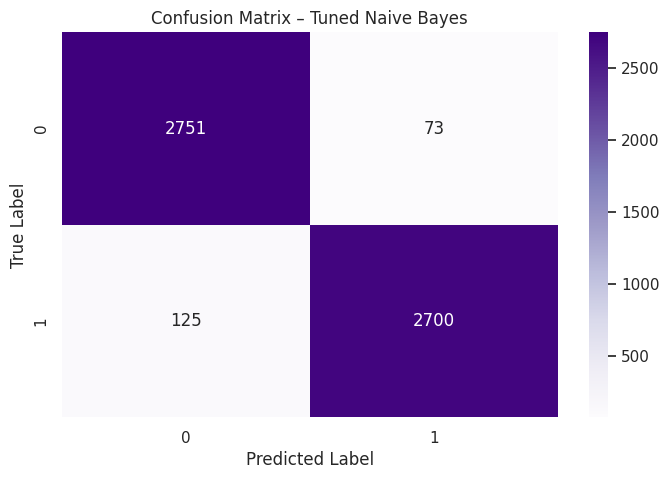


===== Classification Report (Tuned Model) =====
              precision    recall  f1-score   support

           0     0.9565    0.9742    0.9653      2824
           1     0.9737    0.9558    0.9646      2825

    accuracy                         0.9649      5649
   macro avg     0.9651    0.9650    0.9649      5649
weighted avg     0.9651    0.9649    0.9649      5649


Overall Test Accuracy: 0.9649
Precision: 0.9737
Recall:    0.9558
F1 Score:  0.9646


In [22]:
# Confusion Matrix Heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix – Tuned Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n===== Classification Report (Tuned Model) =====")
print(classification_report(y_test, y_test_pred, digits=4))

# Metrics
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"\nOverall Test Accuracy: {test_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

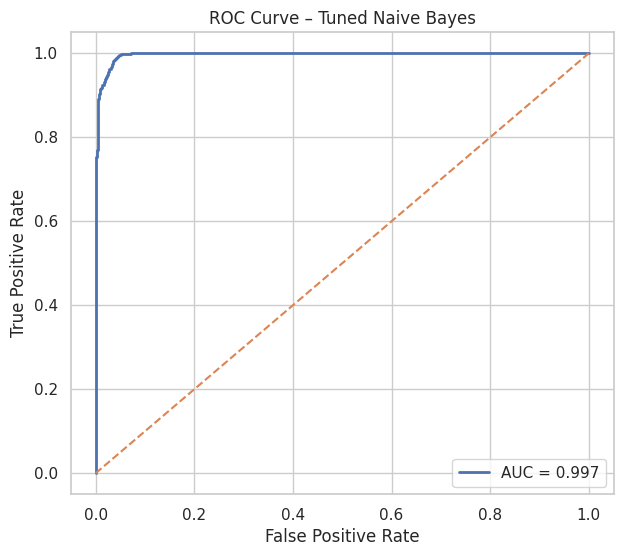

ROC AUC Score: 0.9968179197272431


In [23]:
# =========================
# 11. ROC CURVE (TUNED MODEL)
# =========================
# only if predict_proba available
if proba_available:
    y_probs = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = roc_auc_score(y_test, y_probs)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title("ROC Curve – Tuned Naive Bayes")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()
    print("ROC AUC Score:", roc_auc)
else:
    print("predict_proba not available for the selected classifier — ROC AUC skipped.")

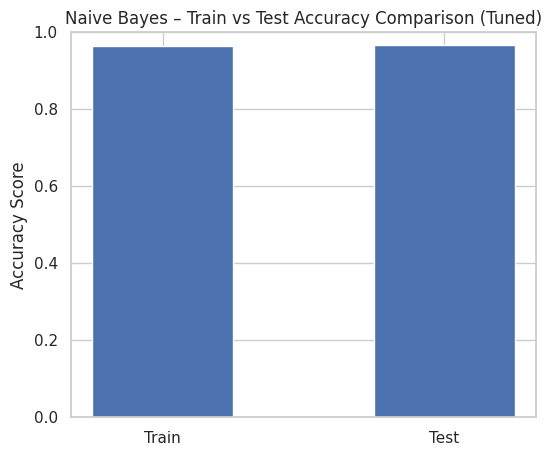

In [24]:
# =========================
# 12. SIMPLE ACCURACY GRAPH (TRAIN vs TEST) (UNCHANGED)
# =========================
plt.figure(figsize=(6,5))
plt.bar(["Train", "Test"], [train_acc, test_acc], width=0.5)
plt.ylim(0, 1)
plt.title("Naive Bayes – Train vs Test Accuracy Comparison (Tuned)")
plt.ylabel("Accuracy Score")
plt.show()